# Lesson 2 Lab – Data Warehousing & OLAP Analysis
## NovaTech Electronics Retail – Multidimensional Sales Analysis
**Student:** Abhishek | **Course:** CSE 315 Data Warehousing & Data Mining (Poshan Karki)

---
**Dataset:** Synthetic electronics retail transactions for *NovaTech Retail Systems*, a global electronics chain operating in 7 cities.  
**Dimensions:** Product, City, Store Address, Date, Quarter  
**Measures:** Unit Price, Quantity Sold, Total Revenue

## Cell 1 – Import All Libraries

In [54]:
%pip install pandas numpy plotly seaborn matplotlib networkx scikit-learn

In [55]:
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")

✅ All libraries imported successfully.
   Pandas  : 2.3.3
   NumPy   : 2.2.6


## Cell 2 – Define Dataset Domains (Products, Cities, Stores)

In [56]:
np.random.seed(2025)  # Reproducibility
NUM_RECORDS = 4000

# --- Product Catalogue ---
PRODUCTS = [
    "Smart TV", "Gaming Laptop", "Wireless Earbuds",
    "Tablet Pro", "Smart Watch", "4K Camera", "Gaming Console"
]

# --- City → Store Address Map (supports Drill-Down) ---
CITY_STORES = {
    "London":     ["12 Oxford St, W1D 1AB",  "88 Regent Ave, SW1A 2AA"],
    "New York":   ["350 5th Ave, NY 10118",   "200 Broadway, NY 10007"],
    "Tokyo":      ["1-1 Akihabara, Chiyoda",  "3-5 Shinjuku, Shinjuku-ku"],
    "Dubai":      ["Mall of Emirates, B1-45", "Dubai Mall, Level 2, S12"],
    "Sydney":     ["88 George St, NSW 2000",  "City Centre, Pitt St Mall"],
    "Berlin":     ["Alexanderplatz 5, 10178", "Kurfurstendamm 22, 10719"],
    "Kathmandu":  ["New Road, Kathmandu 44600","Durbar Marg, KTM 44601"]
}

CITIES = list(CITY_STORES.keys())
print(f"✅ Domain defined: {len(PRODUCTS)} products across {len(CITIES)} cities")
print(f"   Products : {PRODUCTS}")
print(f"   Cities   : {CITIES}")

✅ Domain defined: 7 products across 7 cities
   Products : ['Smart TV', 'Gaming Laptop', 'Wireless Earbuds', 'Tablet Pro', 'Smart Watch', '4K Camera', 'Gaming Console']
   Cities   : ['London', 'New York', 'Tokyo', 'Dubai', 'Sydney', 'Berlin', 'Kathmandu']


## Cell 3 – Generate Source A: Raw JSON Data (With Intentional Noise)

In [57]:
os.makedirs('data_lake', exist_ok=True)

json_records = []
for i in range(NUM_RECORDS):
    city   = np.random.choice(CITIES + [None, "UNKNOWN"])  # Inject nulls
    price  = round(np.random.uniform(50, 2500), 2)
    qty    = np.random.randint(1, 8)
    date   = pd.Timestamp('2024-01-01') + pd.Timedelta(days=int(np.random.randint(0, 365)))

    # ~6% price noise: strings instead of numbers
    if np.random.rand() < 0.06:
        price = np.random.choice(["REFUNDED", "$PENDING", "N/A", "--"])

    json_records.append({
        "txn_id":   f"J-{i:05d}",
        "meta":     {"date": date.strftime('%Y-%m-%d'), "city": city},
        "product":  np.random.choice(PRODUCTS + ["??UNKNOWN??", "CORRUPTED"]),  # Bad entries
        "qty":      qty,
        "price":    price
    })

# Inject 150 exact duplicates
json_records += json_records[:150]

with open('data_lake/source_A_transactions.json', 'w') as f:
    json.dump(json_records, f, indent=2)

print(f"✅ Source A (JSON) saved → {len(json_records)} records (including 150 duplicates)")
print("   File: data_lake/source_A_transactions.json")

✅ Source A (JSON) saved → 4150 records (including 150 duplicates)
   File: data_lake/source_A_transactions.json


## Cell 4 – Generate Source B: Raw CSV Data (With Intentional Noise)

In [58]:
csv_rows = []
for i in range(NUM_RECORDS):
    city  = np.random.choice(CITIES)
    store = np.random.choice(CITY_STORES[city])
    qty   = int(np.random.randint(1, 10))
    price = round(np.random.uniform(-300, 3000), 2)  # Negative price outliers
    date  = pd.Timestamp('2024-01-01') + pd.Timedelta(days=int(np.random.randint(0, 365)))

    # ~5% quantity noise
    if np.random.rand() < 0.05:
        qty = np.random.choice([None, "QTY_ERR", "MISSING"])

    csv_rows.append({
        "LOG_ID":        f"C-{i:05d}",
        "EVENT_DATE":    date.strftime('%d/%m/%Y'),    # Different date format (noise)
        "CITY":          city,
        "STORE_ADDRESS": store,
        "PRODUCT":       np.random.choice(PRODUCTS),
        "UNITS_SOLD":    qty,
        "UNIT_PRICE":    price
    })

df_csv_raw = pd.DataFrame(csv_rows)
df_csv_raw.to_csv('data_lake/source_B_logs.csv', index=False)

print(f"✅ Source B (CSV) saved → {len(csv_rows)} records")
print("   File: data_lake/source_B_logs.csv")
print(f"   Negative price rows injected: ~{(df_csv_raw['UNIT_PRICE'] < 0).sum()}")

✅ Source B (CSV) saved → 4000 records
   File: data_lake/source_B_logs.csv
   Negative price rows injected: ~383


---
## PART 2: EXPLORATORY DATA ANALYSIS (EDA)
---

## Cell 5 – Load JSON and Display First 10 Rows

In [59]:
with open('data_lake/source_A_transactions.json', 'r') as f:
    raw_json = json.load(f)

df_json = pd.DataFrame(raw_json)
# Flatten nested 'meta' dict
df_json['date'] = df_json['meta'].apply(lambda x: x['date'])
df_json['city'] = df_json['meta'].apply(lambda x: x['city'])
df_json = df_json.drop(columns=['meta'])

print("📋 Source A (JSON) — First 10 Rows:")
df_json.head(10)

📋 Source A (JSON) — First 10 Rows:


,txn_id,product,qty,price,date,city
0,J-00000,Smart TV,1,886.44,2024-11-19,Tokyo
1,J-00001,4K Camera,3,753.2,2024-07-25,Kathmandu
2,J-00002,Tablet Pro,5,981.61,2024-05-24,None
3,J-00003,Smart TV,1,939.86,2024-04-29,Sydney
4,J-00004,Smart Watch,6,785.28,2024-03-31,New York
5,J-00005,4K Camera,5,2368.05,2024-02-22,Berlin
6,J-00006,Smart Watch,2,203.67,2024-11-07,Berlin
7,J-00007,CORRUPTED,1,N/A,2024-06-22,UNKNOWN
8,J-00008,Smart TV,6,2310.4,2024-07-08,Kathmandu
9,J-00009,Gaming Console,1,479.7,2024-04-08,Tokyo


## Cell 6 – Load CSV and Display First 10 Rows

In [60]:
df_csv = pd.read_csv('data_lake/source_B_logs.csv')

print("📋 Source B (CSV) — First 10 Rows:")
df_csv.head(10)

📋 Source B (CSV) — First 10 Rows:


,LOG_ID,EVENT_DATE,CITY,STORE_ADDRESS,PRODUCT,UNITS_SOLD,UNIT_PRICE
0,C-00000,10/07/2024,Dubai,"Mall of Emirates, B1-45",Smart TV,2,937.49
1,C-00001,04/02/2024,New York,"200 Broadway, NY 10007",Wireless Earbuds,2,2480.85
2,C-00002,28/03/2024,Kathmandu,"New Road, Kathmandu 44600",Smart TV,6,430.34
3,C-00003,15/07/2024,New York,"200 Broadway, NY 10007",4K Camera,5,873.87
4,C-00004,24/01/2024,Dubai,"Mall of Emirates, B1-45",4K Camera,QTY_ERR,2708.15
5,C-00005,03/03/2024,Kathmandu,"New Road, Kathmandu 44600",Gaming Console,3,1591.13
6,C-00006,18/11/2024,Tokyo,"1-1 Akihabara, Chiyoda",Wireless Earbuds,9,2042.10
7,C-00007,11/06/2024,Sydney,"City Centre, Pitt St Mall",Gaming Console,1,363.37
8,C-00008,26/01/2024,Dubai,"Dubai Mall, Level 2, S12",Gaming Console,6,1700.51
9,C-00009,01/06/2024,Berlin,"Alexanderplatz 5, 10178",Gaming Console,8,2828.30


## Cell 7 – Column Names and Data Types (JSON Source)

In [61]:
print("=" * 50)
print("Source A (JSON) — Column Names & Data Types")
print("=" * 50)
print("\n.columns:")
print(df_json.columns.tolist())
print("\n.dtypes:")
print(df_json.dtypes)

Source A (JSON) — Column Names & Data Types

.columns:
['txn_id', 'product', 'qty', 'price', 'date', 'city']

.dtypes:
txn_id     object
product    object
qty         int64
price      object
date       object
city       object
dtype: object


## Cell 8 – Column Names and Data Types (CSV Source)

In [62]:
print("=" * 50)
print("Source B (CSV) — Column Names & Data Types")
print("=" * 50)
print("\n.columns:")
print(df_csv.columns.tolist())
print("\n.dtypes:")
print(df_csv.dtypes)

Source B (CSV) — Column Names & Data Types

.columns:
['LOG_ID', 'EVENT_DATE', 'CITY', 'STORE_ADDRESS', 'PRODUCT', 'UNITS_SOLD', 'UNIT_PRICE']

.dtypes:
LOG_ID            object
EVENT_DATE        object
CITY              object
STORE_ADDRESS     object
PRODUCT           object
UNITS_SOLD        object
UNIT_PRICE       float64
dtype: object


## Cell 9 – Shape, Size, Info (JSON Source)

In [63]:
print(f"Shape  (rows × cols) : {df_json.shape}")
print(f"Size   (total cells) : {df_json.size}")
print()
print("--- .info() ---")
df_json.info()

Shape  (rows × cols) : (4150, 6)
Size   (total cells) : 24900

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4150 entries, 0 to 4149
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   txn_id   4150 non-null   object
 1   product  4150 non-null   object
 2   qty      4150 non-null   int64 
 3   price    4150 non-null   object
 4   date     4150 non-null   object
 5   city     3650 non-null   object
dtypes: int64(1), object(5)
memory usage: 194.7+ KB


## Cell 10 – Shape, Size, Info (CSV Source)

In [64]:
print(f"Shape  (rows × cols) : {df_csv.shape}")
print(f"Size   (total cells) : {df_csv.size}")
print()
print("--- .info() ---")
df_csv.info()

Shape  (rows × cols) : (4000, 7)
Size   (total cells) : 28000

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   LOG_ID         4000 non-null   object 
 1   EVENT_DATE     4000 non-null   object 
 2   CITY           4000 non-null   object 
 3   STORE_ADDRESS  4000 non-null   object 
 4   PRODUCT        4000 non-null   object 
 5   UNITS_SOLD     3929 non-null   object 
 6   UNIT_PRICE     4000 non-null   float64
dtypes: float64(1), object(6)
memory usage: 218.9+ KB


## Cell 11 – Statistical Summary (.describe)

In [65]:
print("=== Source A (JSON) — Statistical Summary ===")
print(df_json.describe(include='all').T)

print("\n=== Source B (CSV) — Statistical Summary ===")
print(df_csv.describe(include='all').T)

=== Source A (JSON) — Statistical Summary ===
          count unique               top freq      mean       std  min  25%  \
txn_id     4150   4000           J-00134    2       NaN       NaN  NaN  NaN   
product    4150      9  Wireless Earbuds  485       NaN       NaN  NaN  NaN   
qty      4150.0    NaN               NaN  NaN  4.001446  1.999517  1.0  2.0   
price      4150   3724               N/A   79       NaN       NaN  NaN  NaN   
date       4150    365        2024-06-14   24       NaN       NaN  NaN  NaN   
city       3650      8            London  513       NaN       NaN  NaN  NaN   

         50%  75%  max  
txn_id   NaN  NaN  NaN  
product  NaN  NaN  NaN  
qty      4.0  6.0  7.0  
price    NaN  NaN  NaN  
date     NaN  NaN  NaN  
city     NaN  NaN  NaN  

=== Source B (CSV) — Statistical Summary ===
                count unique                      top freq         mean  \
LOG_ID           4000   4000                  C-03983    1          NaN   
EVENT_DATE       4000    365 

## Cell 12 – Missing Value Count per Column

In [66]:
print("=== Null/Missing Value Count — Source A (JSON) ===")
print(df_json.isnull().sum())
print(f"  → Total missing : {df_json.isnull().sum().sum()}")

print("\n=== Null/Missing Value Count — Source B (CSV) ===")
print(df_csv.isnull().sum())
print(f"  → Total missing : {df_csv.isnull().sum().sum()}")

=== Null/Missing Value Count — Source A (JSON) ===
txn_id       0
product      0
qty          0
price        0
date         0
city       500
dtype: int64
  → Total missing : 500

=== Null/Missing Value Count — Source B (CSV) ===
LOG_ID            0
EVENT_DATE        0
CITY              0
STORE_ADDRESS     0
PRODUCT           0
UNITS_SOLD       71
UNIT_PRICE        0
dtype: int64
  → Total missing : 71


## Cell 13 – Identify Malformed (String) Prices in JSON Source

In [67]:
# Find non-numeric price values (type mix-ups)
malformed_prices = df_json[pd.to_numeric(df_json['price'], errors='coerce').isna()]
print(f"Total malformed price entries: {len(malformed_prices)}")
print("\nUnique malformed price string values:")
print(malformed_prices['price'].unique())
print("\nSample malformed rows:")
print(malformed_prices[['txn_id', 'product', 'price', 'city']].head(8))

Total malformed price entries: 265

Unique malformed price string values:
['N/A' '$PENDING' 'REFUNDED' '--']

Sample malformed rows:
      txn_id           product     price       city
7    J-00007         CORRUPTED       N/A    UNKNOWN
16   J-00016  Wireless Earbuds  $PENDING     Berlin
21   J-00021        Tablet Pro  REFUNDED  Kathmandu
29   J-00029  Wireless Earbuds  REFUNDED     London
56   J-00056        Tablet Pro       N/A     Sydney
57   J-00057     Gaming Laptop       N/A       None
68   J-00068        Tablet Pro       N/A    UNKNOWN
112  J-00112       Smart Watch       N/A   New York


## Cell 14 – Identify Corrupted Product Names in JSON

In [68]:
valid_products = set(PRODUCTS)
bad_products = df_json[~df_json['product'].isin(valid_products)]

print(f"Corrupted product entries: {len(bad_products)}")
print("\nUnique corrupted product values:")
print(bad_products['product'].unique())

Corrupted product entries: 934

Unique corrupted product values:
['CORRUPTED' '??UNKNOWN??']


## Cell 15 – Visualize Price Outliers: Boxplot (CSV Source)

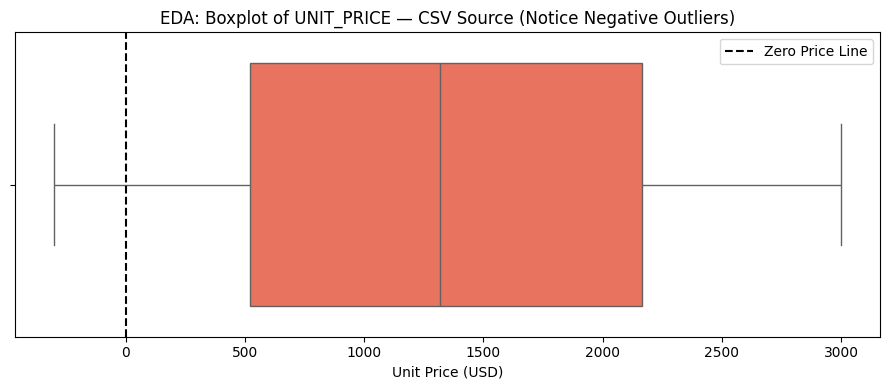


⚠️  Negative price rows detected: 383


In [69]:
plt.figure(figsize=(9, 4))
sns.boxplot(x=df_csv['UNIT_PRICE'], color='tomato')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Zero Price Line')
plt.title("EDA: Boxplot of UNIT_PRICE — CSV Source (Notice Negative Outliers)")
plt.xlabel("Unit Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

neg_count = (df_csv['UNIT_PRICE'] < 0).sum()
print(f"\n⚠️  Negative price rows detected: {neg_count}")

## Cell 16 – Visualize Price Distribution: Histogram

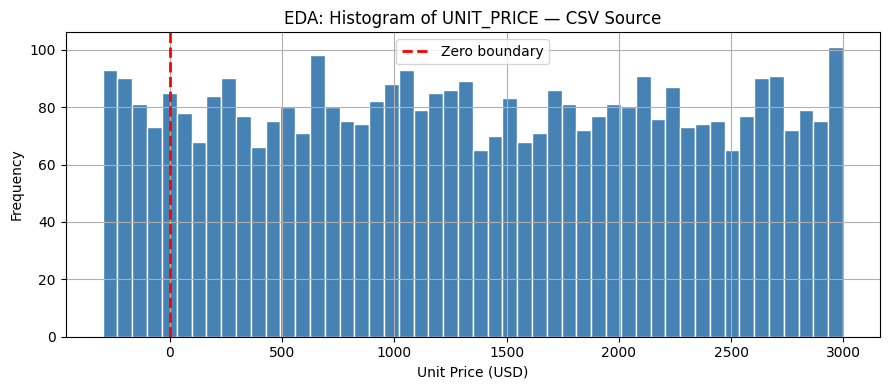

In [70]:
plt.figure(figsize=(9, 4))
df_csv['UNIT_PRICE'].hist(bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero boundary')
plt.title("EDA: Histogram of UNIT_PRICE — CSV Source")
plt.xlabel("Unit Price (USD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 17 – Value Range Check: Min, Max, Unique counts

In [71]:
print("=== CSV: Price Range Check ===")
print(f"  Min  UNIT_PRICE : {df_csv['UNIT_PRICE'].min():.2f}")
print(f"  Max  UNIT_PRICE : {df_csv['UNIT_PRICE'].max():.2f}")
print(f"  Mean UNIT_PRICE : {df_csv['UNIT_PRICE'].mean():.2f}")

print("\n=== CSV: Unique Values per Column ===")
for col in df_csv.columns:
    print(f"  {col:<20} : {df_csv[col].nunique()} unique")

=== CSV: Price Range Check ===
  Min  UNIT_PRICE : -299.86
  Max  UNIT_PRICE : 2998.82
  Mean UNIT_PRICE : 1344.79

=== CSV: Unique Values per Column ===
  LOG_ID               : 4000 unique
  EVENT_DATE           : 365 unique
  CITY                 : 7 unique
  STORE_ADDRESS        : 14 unique
  PRODUCT              : 7 unique
  UNITS_SOLD           : 11 unique
  UNIT_PRICE           : 3982 unique


---
## PART 3: DATA CLEANING AND TRANSFORMATION (ETL Pipeline)
---

## Cell 18 – Standardize and Merge Both Sources

In [72]:
# --- Standardize JSON Source ---
df_json_std = df_json[['txn_id', 'date', 'city', 'product', 'qty', 'price']].copy()
df_json_std.columns = ['TXN_ID', 'DATE', 'CITY', 'PRODUCT', 'QUANTITY', 'UNIT_PRICE']
df_json_std['STORE_ADDRESS'] = np.nan  # JSON has no store address

# --- Standardize CSV Source ---
df_csv_std = df_csv[['LOG_ID', 'EVENT_DATE', 'CITY', 'STORE_ADDRESS', 'PRODUCT', 'UNITS_SOLD', 'UNIT_PRICE']].copy()
df_csv_std.columns = ['TXN_ID', 'DATE', 'CITY', 'STORE_ADDRESS', 'PRODUCT', 'QUANTITY', 'UNIT_PRICE']

# --- Merge (Union) ---
merged = pd.concat([df_json_std, df_csv_std], ignore_index=True)

print(f"✅ Merged dataset shape: {merged.shape}")
print(f"   JSON rows : {len(df_json_std)}")
print(f"   CSV rows  : {len(df_csv_std)}")
merged.head(5)

✅ Merged dataset shape: (8150, 7)
   JSON rows : 4150
   CSV rows  : 4000


,TXN_ID,DATE,CITY,PRODUCT,QUANTITY,UNIT_PRICE,STORE_ADDRESS
0,J-00000,2024-11-19,Tokyo,Smart TV,1,886.44,NaN
1,J-00001,2024-07-25,Kathmandu,4K Camera,3,753.2,NaN
2,J-00002,2024-05-24,None,Tablet Pro,5,981.61,NaN
3,J-00003,2024-04-29,Sydney,Smart TV,1,939.86,NaN
4,J-00004,2024-03-31,New York,Smart Watch,6,785.28,NaN


## Cell 19 – Fix Data Types (Coerce Errors to NaN)

In [73]:
before_fix = len(merged)

# Convert malformed price and quantity to NaN
merged['UNIT_PRICE'] = pd.to_numeric(merged['UNIT_PRICE'], errors='coerce')
merged['QUANTITY']   = pd.to_numeric(merged['QUANTITY'],   errors='coerce')

# Parse dates — handle both date formats
merged['DATE'] = pd.to_datetime(merged['DATE'], dayfirst=True, errors='coerce')

print(f"After type coercion — NaN counts:")
print(merged[['UNIT_PRICE', 'QUANTITY', 'DATE', 'CITY']].isnull().sum())
print(f"\nDataset size before: {before_fix}")

After type coercion — NaN counts:
UNIT_PRICE     265
QUANTITY       213
DATE          4000
CITY           500
dtype: int64

Dataset size before: 8150


## Cell 20 – Imputation: Fill Missing Quantity with Median

In [74]:
median_qty = merged['QUANTITY'].median()
merged['QUANTITY'] = merged['QUANTITY'].fillna(median_qty)

print(f"✅ Missing QUANTITY filled with median value: {median_qty}")
print(f"   Remaining QUANTITY nulls: {merged['QUANTITY'].isnull().sum()}")

✅ Missing QUANTITY filled with median value: 4.0
   Remaining QUANTITY nulls: 0


## Cell 21 – Drop Duplicates, Nulls, Outliers, Bad Products

In [75]:
before = len(merged)

# Drop duplicates
merged = merged.drop_duplicates(subset='TXN_ID')
after_dup = len(merged)

# Drop rows with missing city or price
merged = merged.dropna(subset=['CITY', 'UNIT_PRICE', 'DATE'])
after_null = len(merged)

# Remove unknown/null cities
merged = merged[merged['CITY'].isin(CITIES)]
after_city = len(merged)

# Remove negative/zero prices
merged = merged[merged['UNIT_PRICE'] > 0]
after_price = len(merged)

# Remove corrupted product names
merged = merged[merged['PRODUCT'].isin(PRODUCTS)]
after_prod = len(merged)

print(f"Records removed:")
print(f"  Duplicates removed      : {before - after_dup}")
print(f"  Null rows dropped       : {after_dup - after_null}")
print(f"  Unknown city removed    : {after_null - after_city}")
print(f"  Negative price removed  : {after_city - after_price}")
print(f"  Bad product removed     : {after_price - after_prod}")
print(f"\n✅ Final clean dataset: {after_prod} rows")

Records removed:
  Duplicates removed      : 150
  Null rows dropped       : 4692
  Unknown city removed    : 408
  Negative price removed  : 0
  Bad product removed     : 658

✅ Final clean dataset: 2242 rows


## Cell 22 – Feature Engineering: Revenue, Quarter, Season, Year, Month

In [76]:
df = merged.copy()

# Revenue calculation
df['REVENUE'] = (df['QUANTITY'] * df['UNIT_PRICE']).round(2)

# Time hierarchy features
df['YEAR']    = df['DATE'].dt.year
df['MONTH']   = df['DATE'].dt.month_name()
df['MONTH_NUM'] = df['DATE'].dt.month
df['QUARTER'] = 'Q' + df['DATE'].dt.quarter.astype(str)
df['DAY']     = df['DATE'].dt.day
df['WEEK']    = df['DATE'].dt.isocalendar().week.astype(int)

# Store_Code encoding (for ML-readiness)
df['CITY_CODE'] = df['CITY'].astype('category').cat.codes

print("✅ Feature Engineering complete.")
print(f"   New columns added: REVENUE, YEAR, MONTH, QUARTER, DAY, WEEK, CITY_CODE")
print(f"\nFinal DataFrame shape: {df.shape}")
df.head(6)

✅ Feature Engineering complete.
   New columns added: REVENUE, YEAR, MONTH, QUARTER, DAY, WEEK, CITY_CODE

Final DataFrame shape: (2242, 15)


,TXN_ID,DATE,CITY,PRODUCT,QUANTITY,UNIT_PRICE,STORE_ADDRESS,REVENUE,YEAR,MONTH,MONTH_NUM,QUARTER,DAY,WEEK,CITY_CODE
0,J-00000,2024-11-19,Tokyo,Smart TV,1.0,886.44,NaN,886.44,2024,November,11,Q4,19,47,6
1,J-00001,2024-07-25,Kathmandu,4K Camera,3.0,753.20,NaN,2259.60,2024,July,7,Q3,25,30,2
3,J-00003,2024-04-29,Sydney,Smart TV,1.0,939.86,NaN,939.86,2024,April,4,Q2,29,18,5
4,J-00004,2024-03-31,New York,Smart Watch,6.0,785.28,NaN,4711.68,2024,March,3,Q1,31,13,4
5,J-00005,2024-02-22,Berlin,4K Camera,5.0,2368.05,NaN,11840.25,2024,February,2,Q1,22,8,0
6,J-00006,2024-11-07,Berlin,Smart Watch,2.0,203.67,NaN,407.34,2024,November,11,Q4,7,45,0


## Cell 23 – Fill Missing Store Address from City Lookup

In [77]:
# JSON rows had no STORE_ADDRESS — assign a random store from the city
def assign_store(row):
    if pd.isna(row['STORE_ADDRESS']):
        return np.random.choice(CITY_STORES.get(row['CITY'], ['Store Unknown']))
    return row['STORE_ADDRESS']

df['STORE_ADDRESS'] = df.apply(assign_store, axis=1)

print("✅ Missing store addresses filled from City lookup table.")
print(f"   Null STORE_ADDRESS remaining: {df['STORE_ADDRESS'].isnull().sum()}")
print("\nSample City → Store Address mapping:")
print(df[['CITY', 'STORE_ADDRESS']].drop_duplicates().sort_values('CITY').head(10))

✅ Missing store addresses filled from City lookup table.
   Null STORE_ADDRESS remaining: 0

Sample City → Store Address mapping:
         CITY              STORE_ADDRESS
5      Berlin    Alexanderplatz 5, 10178
6      Berlin   Kurfurstendamm 22, 10719
19      Dubai   Dubai Mall, Level 2, S12
39      Dubai    Mall of Emirates, B1-45
1   Kathmandu  New Road, Kathmandu 44600
10  Kathmandu     Durbar Marg, KTM 44601
22     London      12 Oxford St, W1D 1AB
31     London    88 Regent Ave, SW1A 2AA
4    New York     200 Broadway, NY 10007
28   New York      350 5th Ave, NY 10118


## Cell 24 – Identify Dimensions and Measures

In [78]:
DIMENSIONS = ['PRODUCT', 'CITY', 'STORE_ADDRESS', 'QUARTER', 'YEAR', 'MONTH', 'DATE']
MEASURES   = ['UNIT_PRICE', 'QUANTITY', 'REVENUE']

print("📐 DIMENSIONS (Categorical — used for grouping, slicing, filtering):")
for d in DIMENSIONS:
    print(f"   {d:<20} → dtype: {df[d].dtype}")

print("\n📊 MEASURES (Numerical — what we aggregate/analyze):")
for m in MEASURES:
    print(f"   {m:<20} → dtype: {df[m].dtype}")

📐 DIMENSIONS (Categorical — used for grouping, slicing, filtering):
   PRODUCT              → dtype: object
   CITY                 → dtype: object
   STORE_ADDRESS        → dtype: object
   QUARTER              → dtype: object
   YEAR                 → dtype: int32
   MONTH                → dtype: object
   DATE                 → dtype: datetime64[ns]

📊 MEASURES (Numerical — what we aggregate/analyze):
   UNIT_PRICE           → dtype: float64
   QUANTITY             → dtype: float64
   REVENUE              → dtype: float64


## Cell 25 – Big Picture View: Mean and Max of Primary Sales Attribute (REVENUE)

In [79]:
print("=" * 45)
print("  Big Picture — Primary Sales Attribute: REVENUE")
print("=" * 45)
print(f"  Total Transactions  : {len(df):,}")
print(f"  Total Revenue       : ${df['REVENUE'].sum():,.2f}")
print(f"  Mean Revenue        : ${df['REVENUE'].mean():,.2f}")
print(f"  Max  Revenue        : ${df['REVENUE'].max():,.2f}")
print(f"  Min  Revenue        : ${df['REVENUE'].min():,.2f}")
print(f"  Std  Dev Revenue    : ${df['REVENUE'].std():,.2f}")

print("\n--- Mean & Max per Product ---")
print(df.groupby('PRODUCT')['REVENUE'].agg(['mean','max']).round(2))

  Big Picture — Primary Sales Attribute: REVENUE
  Total Transactions  : 2,242
  Total Revenue       : $11,345,870.50
  Mean Revenue        : $5,060.60
  Max  Revenue        : $17,367.77
  Min  Revenue        : $56.37
  Std  Dev Revenue    : $4,022.55

--- Mean & Max per Product ---
                     mean       max
PRODUCT                            
4K Camera         5147.39  16771.23
Gaming Console    5061.23  17367.77
Gaming Laptop     4919.93  16409.26
Smart TV          5177.94  17246.95
Smart Watch       4891.16  17351.88
Tablet Pro        5104.10  17351.81
Wireless Earbuds  5114.14  16968.77


## Cell 26 – Save Final Clean Data to CSV and JSON

In [80]:
os.makedirs('data_warehouse', exist_ok=True)

# Save CSV
df.to_csv('data_warehouse/novatech_clean.csv', index=False)

# Save JSON
df.to_json('data_warehouse/novatech_clean.json', orient='records', indent=2,
           date_format='iso')

print("✅ Clean data saved to:")
print("   data_warehouse/novatech_clean.csv")
print("   data_warehouse/novatech_clean.json")

# Verify reload
verify = pd.read_csv('data_warehouse/novatech_clean.csv')
print(f"\n✅ Verification — Reloaded CSV shape: {verify.shape}")

✅ Clean data saved to:
   data_warehouse/novatech_clean.csv
   data_warehouse/novatech_clean.json

✅ Verification — Reloaded CSV shape: (2242, 15)


---
## PART 4: DATA WAREHOUSE SCHEMAS
---

## Cell 27 – Build Fact Table and Dimension Tables

In [81]:
# ── FACT TABLE ──────────────────────────────────────────────
fact_sales = df[['TXN_ID', 'DATE', 'CITY', 'STORE_ADDRESS',
                  'PRODUCT', 'QUANTITY', 'UNIT_PRICE', 'REVENUE']].copy()

# ── DIM: TIME ────────────────────────────────────────────────
dim_time = df[['DATE', 'DAY', 'WEEK', 'MONTH', 'MONTH_NUM',
               'QUARTER', 'YEAR']].drop_duplicates().reset_index(drop=True)

# ── DIM: LOCATION (STAR — flat) ──────────────────────────────
dim_location_star = df[['CITY', 'STORE_ADDRESS']].drop_duplicates().reset_index(drop=True)

# ── DIM: PRODUCT (STAR — flat) ───────────────────────────────
product_category = {
    'Smart TV': 'Display',          'Gaming Laptop': 'Computing',
    'Wireless Earbuds': 'Audio',     'Tablet Pro': 'Computing',
    'Smart Watch': 'Wearables',      '4K Camera': 'Imaging',
    'Gaming Console': 'Gaming'
}
dim_product = pd.DataFrame({
    'PRODUCT': list(product_category.keys()),
    'CATEGORY': list(product_category.values())
})

print("✅ Dimension Tables Created:")
print(f"   fact_sales        : {fact_sales.shape}")
print(f"   dim_time          : {dim_time.shape}")
print(f"   dim_location_star : {dim_location_star.shape}")
print(f"   dim_product       : {dim_product.shape}")

✅ Dimension Tables Created:
   fact_sales        : (2242, 8)
   dim_time          : (364, 7)
   dim_location_star : (14, 2)
   dim_product       : (7, 2)


## Cell 28 – Star Schema Diagram

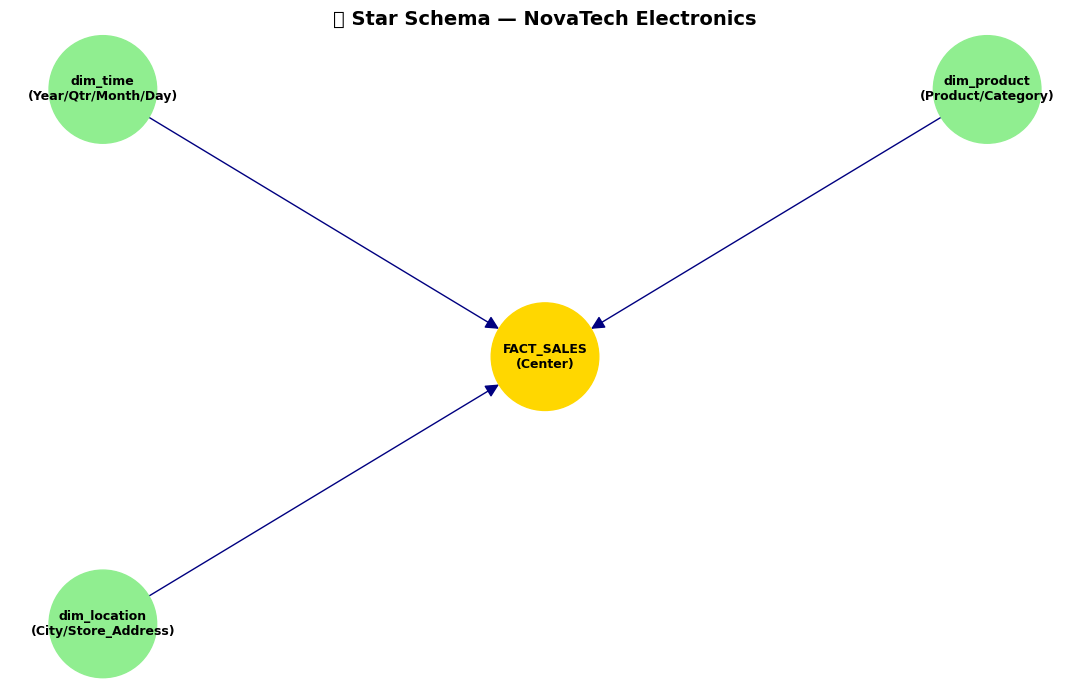

Star Schema: Fact table at center, dimension tables directly connected (flat, not normalized).


In [82]:
fig, ax = plt.subplots(figsize=(11, 7))
G = nx.DiGraph()

nodes = {
    "FACT_SALES\n(Center)": (0, 0),
    "dim_time\n(Year/Qtr/Month/Day)": (-3, 2),
    "dim_product\n(Product/Category)": (3, 2),
    "dim_location\n(City/Store_Address)": (-3, -2),
}
for node, pos in nodes.items():
    G.add_node(node, pos=pos)

edges = [
    ("dim_time\n(Year/Qtr/Month/Day)",    "FACT_SALES\n(Center)"),
    ("dim_product\n(Product/Category)",   "FACT_SALES\n(Center)"),
    ("dim_location\n(City/Store_Address)","FACT_SALES\n(Center)"),
]
G.add_edges_from(edges)

pos   = nx.get_node_attributes(G, 'pos')
color = ['#FFD700', '#90EE90', '#90EE90', '#90EE90']
nx.draw(G, pos, ax=ax, with_labels=True, node_color=color,
        node_size=6000, font_size=9, font_weight='bold', arrows=True,
        arrowsize=20, edge_color='navy')

ax.set_title("⭐ Star Schema — NovaTech Electronics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Star Schema: Fact table at center, dimension tables directly connected (flat, not normalized).")

## Cell 29 – Snowflake Schema: Normalize Location Dimension

In [83]:
# Snowflake: split location into City table and Store table
dim_city = pd.DataFrame({'CITY': CITIES}).reset_index()
dim_city.columns = ['CITY_ID', 'CITY']

store_rows = []
for cid, city in zip(dim_city['CITY_ID'], dim_city['CITY']):
    for addr in CITY_STORES[city]:
        store_rows.append({'CITY_ID': cid, 'STORE_ADDRESS': addr})
dim_store = pd.DataFrame(store_rows)
dim_store.index.name = 'STORE_ID'

print("=== Snowflake: dim_city (normalized) ===")
print(dim_city)
print("\n=== Snowflake: dim_store (references dim_city via CITY_ID) ===")
print(dim_store)

=== Snowflake: dim_city (normalized) ===
   CITY_ID       CITY
0        0     London
1        1   New York
2        2      Tokyo
3        3      Dubai
4        4     Sydney
5        5     Berlin
6        6  Kathmandu

=== Snowflake: dim_store (references dim_city via CITY_ID) ===
          CITY_ID              STORE_ADDRESS
STORE_ID                                    
0               0      12 Oxford St, W1D 1AB
1               0    88 Regent Ave, SW1A 2AA
2               1      350 5th Ave, NY 10118
3               1     200 Broadway, NY 10007
4               2     1-1 Akihabara, Chiyoda
5               2  3-5 Shinjuku, Shinjuku-ku
6               3    Mall of Emirates, B1-45
7               3   Dubai Mall, Level 2, S12
8               4     88 George St, NSW 2000
9               4  City Centre, Pitt St Mall
10              5    Alexanderplatz 5, 10178
11              5   Kurfurstendamm 22, 10719
12              6  New Road, Kathmandu 44600
13              6     Durbar Marg, KTM 44601

## Cell 30 – Snowflake Schema Diagram

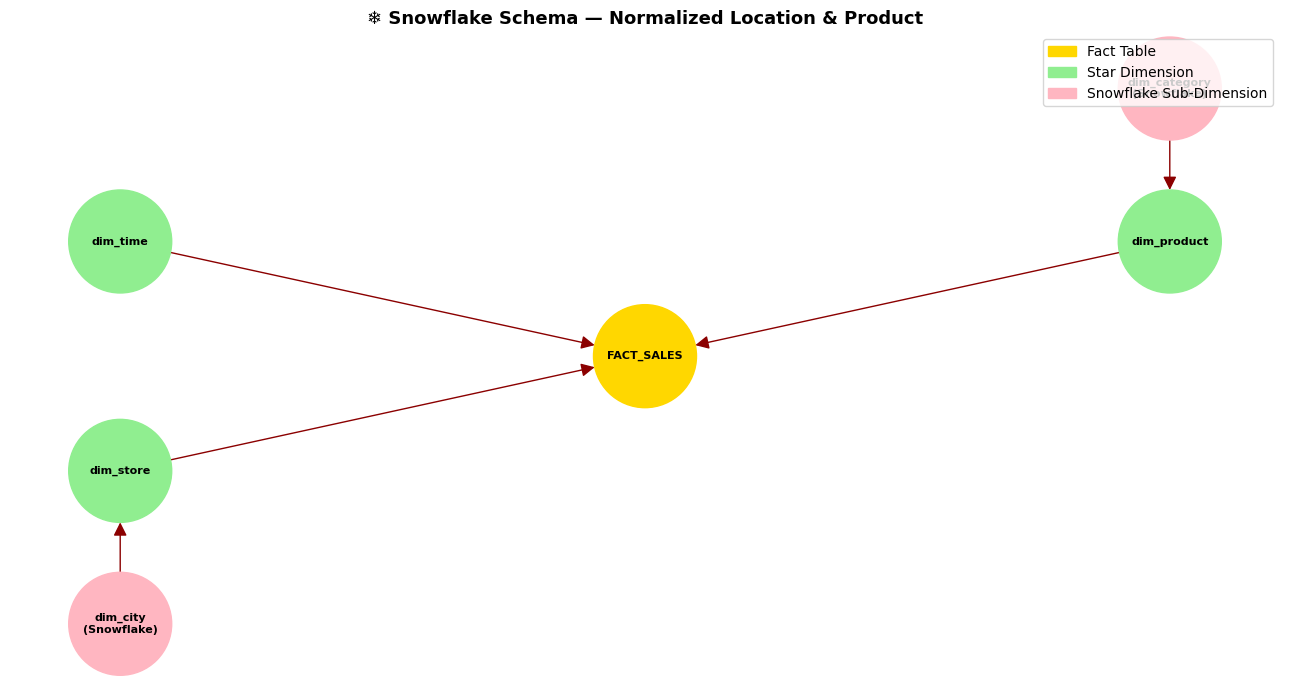

In [84]:
fig, ax = plt.subplots(figsize=(13, 7))
G2 = nx.DiGraph()

nodes2 = {
    "FACT_SALES": (0, 0),
    "dim_time": (-3.5, 1.5),
    "dim_product": (3.5, 1.5),
    "dim_category\n(Snowflake)": (3.5, 3.5),
    "dim_store": (-3.5, -1.5),
    "dim_city\n(Snowflake)": (-3.5, -3.5),
}
for node, pos in nodes2.items():
    G2.add_node(node, pos=pos)

G2.add_edges_from([
    ("dim_time",       "FACT_SALES"),
    ("dim_product",    "FACT_SALES"),
    ("dim_store",      "FACT_SALES"),
    ("dim_category\n(Snowflake)", "dim_product"),
    ("dim_city\n(Snowflake)",     "dim_store"),
])

pos2   = nx.get_node_attributes(G2, 'pos')
color2 = ['#FFD700','#90EE90','#90EE90','#FFB6C1','#90EE90','#FFB6C1']
nx.draw(G2, pos2, ax=ax, with_labels=True, node_color=color2,
        node_size=5500, font_size=8, font_weight='bold', arrows=True,
        arrowsize=20, edge_color='darkred')

ax.set_title("❄️ Snowflake Schema — Normalized Location & Product", fontsize=13, fontweight='bold')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#FFD700', label='Fact Table'),
    plt.Rectangle((0,0),1,1, color='#90EE90', label='Star Dimension'),
    plt.Rectangle((0,0),1,1, color='#FFB6C1', label='Snowflake Sub-Dimension'),
], loc='upper right')
plt.tight_layout()
plt.show()

## Cell 31 – Fact Constellation (Galaxy) Schema

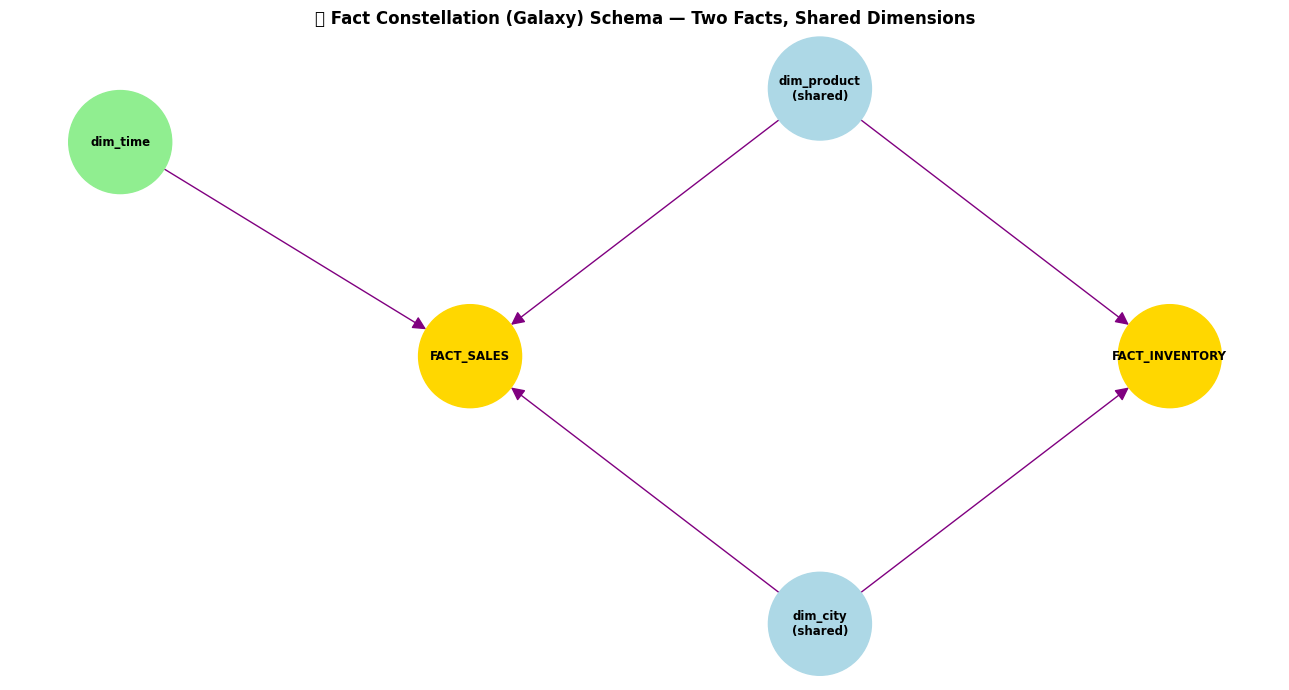

Note: dim_product and dim_city are SHARED between FACT_SALES and FACT_INVENTORY.


In [85]:
# Fact Constellation: Two fact tables sharing common dimensions

# Fact 2: Inventory (hypothetical)
fact_inventory = df.groupby(['PRODUCT','CITY'])['QUANTITY'].sum().reset_index()
fact_inventory.columns = ['PRODUCT','CITY','STOCK_UNITS']

fig, ax = plt.subplots(figsize=(13, 7))
G3 = nx.DiGraph()

nodes3 = {
    "FACT_SALES": (-2.5, 0),
    "FACT_INVENTORY": (2.5, 0),
    "dim_product\n(shared)": (0, 2.5),
    "dim_city\n(shared)": (0, -2.5),
    "dim_time": (-5, 2),
}
for node, pos in nodes3.items():
    G3.add_node(node, pos=pos)

G3.add_edges_from([
    ("dim_product\n(shared)",  "FACT_SALES"),
    ("dim_product\n(shared)",  "FACT_INVENTORY"),
    ("dim_city\n(shared)",     "FACT_SALES"),
    ("dim_city\n(shared)",     "FACT_INVENTORY"),
    ("dim_time",               "FACT_SALES"),
])

pos3   = nx.get_node_attributes(G3, 'pos')
color3 = ['#FFD700','#FFD700','#ADD8E6','#ADD8E6','#90EE90']
nx.draw(G3, pos3, ax=ax, with_labels=True, node_color=color3,
        node_size=5500, font_size=8.5, font_weight='bold', arrows=True,
        arrowsize=20, edge_color='purple')

ax.set_title("🌌 Fact Constellation (Galaxy) Schema — Two Facts, Shared Dimensions",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Note: dim_product and dim_city are SHARED between FACT_SALES and FACT_INVENTORY.")

---
## PART 5: OLAP OPERATIONS
---

## Cell 32 – Build the Merged Data Warehouse DataFrame (dw_df)

In [86]:
# Merge fact with product category (Snowflake dimension)
dw_df = pd.merge(df, dim_product, on='PRODUCT', how='left')

print(f"✅ Data Warehouse DataFrame (dw_df) ready.")
print(f"   Shape: {dw_df.shape}")
print(f"\nColumns available:")
print(dw_df.columns.tolist())
dw_df.head(5)

✅ Data Warehouse DataFrame (dw_df) ready.
   Shape: (2242, 16)

Columns available:
['TXN_ID', 'DATE', 'CITY', 'PRODUCT', 'QUANTITY', 'UNIT_PRICE', 'STORE_ADDRESS', 'REVENUE', 'YEAR', 'MONTH', 'MONTH_NUM', 'QUARTER', 'DAY', 'WEEK', 'CITY_CODE', 'CATEGORY']


,TXN_ID,DATE,CITY,PRODUCT,QUANTITY,UNIT_PRICE,STORE_ADDRESS,REVENUE,YEAR,MONTH,MONTH_NUM,QUARTER,DAY,WEEK,CITY_CODE,CATEGORY
0,J-00000,2024-11-19,Tokyo,Smart TV,1.0,886.44,"3-5 Shinjuku, Shinjuku-ku",886.44,2024,November,11,Q4,19,47,6,Display
1,J-00001,2024-07-25,Kathmandu,4K Camera,3.0,753.20,"New Road, Kathmandu 44600",2259.60,2024,July,7,Q3,25,30,2,Imaging
2,J-00003,2024-04-29,Sydney,Smart TV,1.0,939.86,"88 George St, NSW 2000",939.86,2024,April,4,Q2,29,18,5,Display
3,J-00004,2024-03-31,New York,Smart Watch,6.0,785.28,"200 Broadway, NY 10007",4711.68,2024,March,3,Q1,31,13,4,Wearables
4,J-00005,2024-02-22,Berlin,4K Camera,5.0,2368.05,"Alexanderplatz 5, 10178",11840.25,2024,February,2,Q1,22,8,0,Imaging


## Cell 33 – OLAP SLICE: Filter Q1 Sales Only

In [87]:
# SLICE: One dimension fixed → QUARTER == 'Q1'
slice_Q1 = dw_df[dw_df['QUARTER'] == 'Q1']

print("=" * 50)
print("  OLAP SLICE: Only Q1 (Jan–Mar) Sales")
print("=" * 50)
print(f"  Total rows (full cube)   : {len(dw_df):,}")
print(f"  Rows after Q1 Slice      : {len(slice_Q1):,}")
print(f"  Q1 Total Revenue         : ${slice_Q1['REVENUE'].sum():,.2f}")
print(f"  Q1 Mean Revenue/Txn      : ${slice_Q1['REVENUE'].mean():,.2f}")
print()
print("Q1 Revenue by Product:")
print(slice_Q1.groupby('PRODUCT')['REVENUE'].sum().sort_values(ascending=False).round(2))

  OLAP SLICE: Only Q1 (Jan–Mar) Sales
  Total rows (full cube)   : 2,242
  Rows after Q1 Slice      : 537
  Q1 Total Revenue         : $2,708,040.71
  Q1 Mean Revenue/Txn      : $5,042.91

Q1 Revenue by Product:
PRODUCT
Smart TV            502027.53
Wireless Earbuds    492601.48
4K Camera           424566.76
Smart Watch         391654.22
Gaming Console      325357.19
Tablet Pro          315915.71
Gaming Laptop       255917.82
Name: REVENUE, dtype: float64


## Cell 34 – SLICE Visualization: Q1 Revenue by Product

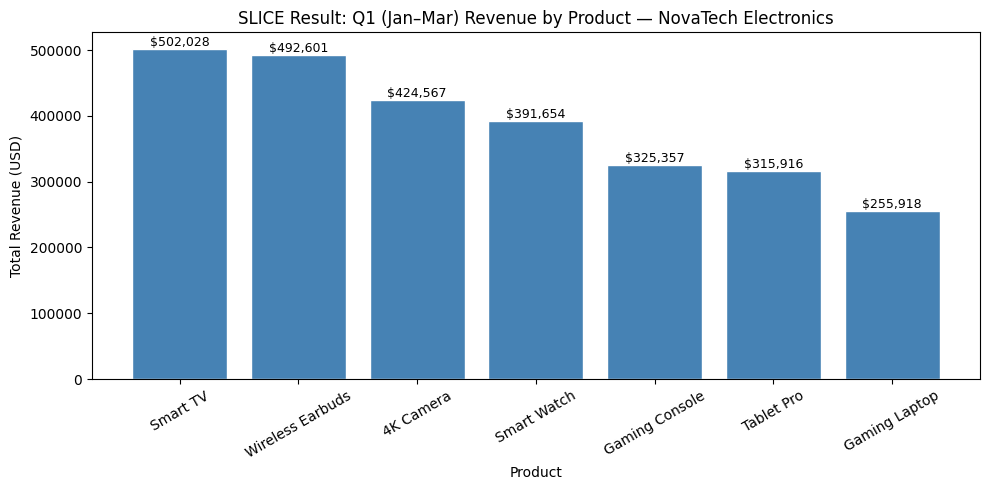

In [88]:
q1_by_product = slice_Q1.groupby('PRODUCT')['REVENUE'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(q1_by_product.index, q1_by_product.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, q1_by_product.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.title("SLICE Result: Q1 (Jan–Mar) Revenue by Product — NovaTech Electronics")
plt.ylabel("Total Revenue (USD)")
plt.xlabel("Product")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Cell 35 – OLAP DICE: Smart TV in London During Q1

In [89]:
# DICE: Multiple dimensions fixed → Product + City + Quarter
dice_tv_london_q1 = dw_df[
    (dw_df['PRODUCT'] == 'Smart TV') &
    (dw_df['CITY']    == 'London')   &
    (dw_df['QUARTER'] == 'Q1')
]

print("=" * 55)
print("  OLAP DICE: Smart TV  ×  London  ×  Q1")
print("=" * 55)
print(f"  Matching transactions  : {len(dice_tv_london_q1):,}")
print(f"  Total Revenue          : ${dice_tv_london_q1['REVENUE'].sum():,.2f}")
print(f"  Units Sold             : {dice_tv_london_q1['QUANTITY'].sum():.0f}")
print(f"  Average Price          : ${dice_tv_london_q1['UNIT_PRICE'].mean():,.2f}")
print()
dice_tv_london_q1[['TXN_ID','DATE','CITY','STORE_ADDRESS','PRODUCT',
                    'QUANTITY','UNIT_PRICE','REVENUE']].head(10)

  OLAP DICE: Smart TV  ×  London  ×  Q1
  Matching transactions  : 10
  Total Revenue          : $60,761.34
  Units Sold             : 40
  Average Price          : $1,330.20



,TXN_ID,DATE,CITY,STORE_ADDRESS,PRODUCT,QUANTITY,UNIT_PRICE,REVENUE
19,J-00031,2024-02-14,London,"88 Regent Ave, SW1A 2AA",Smart TV,4.0,152.45,609.80
267,J-00495,2024-03-26,London,"12 Oxford St, W1D 1AB",Smart TV,3.0,2376.89,7130.67
515,J-00908,2024-01-10,London,"12 Oxford St, W1D 1AB",Smart TV,3.0,1325.77,3977.31
577,J-01027,2024-01-29,London,"88 Regent Ave, SW1A 2AA",Smart TV,4.0,379.74,1518.96
757,J-01327,2024-03-31,London,"88 Regent Ave, SW1A 2AA",Smart TV,5.0,1262.55,6312.75
770,J-01362,2024-01-12,London,"88 Regent Ave, SW1A 2AA",Smart TV,6.0,2468.79,14812.74
877,J-01559,2024-01-03,London,"88 Regent Ave, SW1A 2AA",Smart TV,2.0,685.05,1370.10
989,J-01754,2024-01-26,London,"88 Regent Ave, SW1A 2AA",Smart TV,7.0,2431.99,17023.93
1590,J-02806,2024-03-15,London,"12 Oxford St, W1D 1AB",Smart TV,2.0,435.00,870.00
1865,J-03313,2024-01-07,London,"12 Oxford St, W1D 1AB",Smart TV,4.0,1783.77,7135.08


## Cell 36 – DICE Visualization: TV Sales in London Q1 by Store

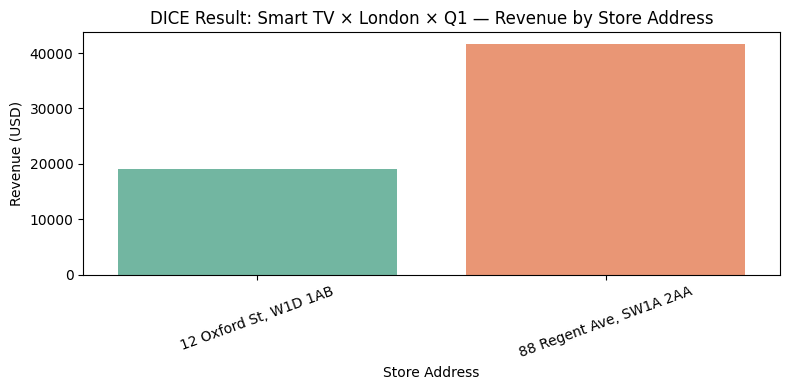

In [90]:
dice_by_store = dice_tv_london_q1.groupby('STORE_ADDRESS')['REVENUE'].sum().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=dice_by_store, x='STORE_ADDRESS', y='REVENUE', palette='Set2')
plt.title("DICE Result: Smart TV × London × Q1 — Revenue by Store Address")
plt.xlabel("Store Address")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Cell 37 – OLAP DRILL-DOWN: City → Store Address

In [91]:
print("=" * 60)
print("  DRILL-DOWN: City Level  →  Store Address Level")
print("=" * 60)

# LEVEL 1: City (high-level, coarse)
city_level = dw_df.groupby('CITY')['REVENUE'].sum().reset_index()
city_level.columns = ['CITY', 'CITY_REVENUE']
city_level = city_level.sort_values('CITY_REVENUE', ascending=False)

print("\n▶ Level 1 — City Summary (Roll-Up View):")
print(city_level.to_string(index=False))

# LEVEL 2: Store Address (drill-down, fine detail)
store_level = dw_df.groupby(['CITY', 'STORE_ADDRESS'])['REVENUE'].sum().reset_index()
store_level.columns = ['CITY', 'STORE_ADDRESS', 'STORE_REVENUE']
store_level = store_level.sort_values(['CITY','STORE_REVENUE'], ascending=[True, False])

print("\n▶ Level 2 — Store Address (Drill-Down View):")
print(store_level.to_string(index=False))

  DRILL-DOWN: City Level  →  Store Address Level

▶ Level 1 — City Summary (Roll-Up View):
     CITY  CITY_REVENUE
   London    1789415.92
Kathmandu    1746442.06
 New York    1600663.08
   Berlin    1592290.25
    Tokyo    1578374.87
   Sydney    1553555.12
    Dubai    1485129.20

▶ Level 2 — Store Address (Drill-Down View):
     CITY             STORE_ADDRESS  STORE_REVENUE
   Berlin  Kurfurstendamm 22, 10719      801611.49
   Berlin   Alexanderplatz 5, 10178      790678.76
    Dubai  Dubai Mall, Level 2, S12      760425.41
    Dubai   Mall of Emirates, B1-45      724703.79
Kathmandu    Durbar Marg, KTM 44601      886772.34
Kathmandu New Road, Kathmandu 44600      859669.72
   London   88 Regent Ave, SW1A 2AA      908107.36
   London     12 Oxford St, W1D 1AB      881308.56
 New York     350 5th Ave, NY 10118      822014.69
 New York    200 Broadway, NY 10007      778648.39
   Sydney City Centre, Pitt St Mall      792538.90
   Sydney    88 George St, NSW 2000      761016.22
    Toky

## Cell 38 – DRILL-DOWN Visualization: City vs Store Revenue

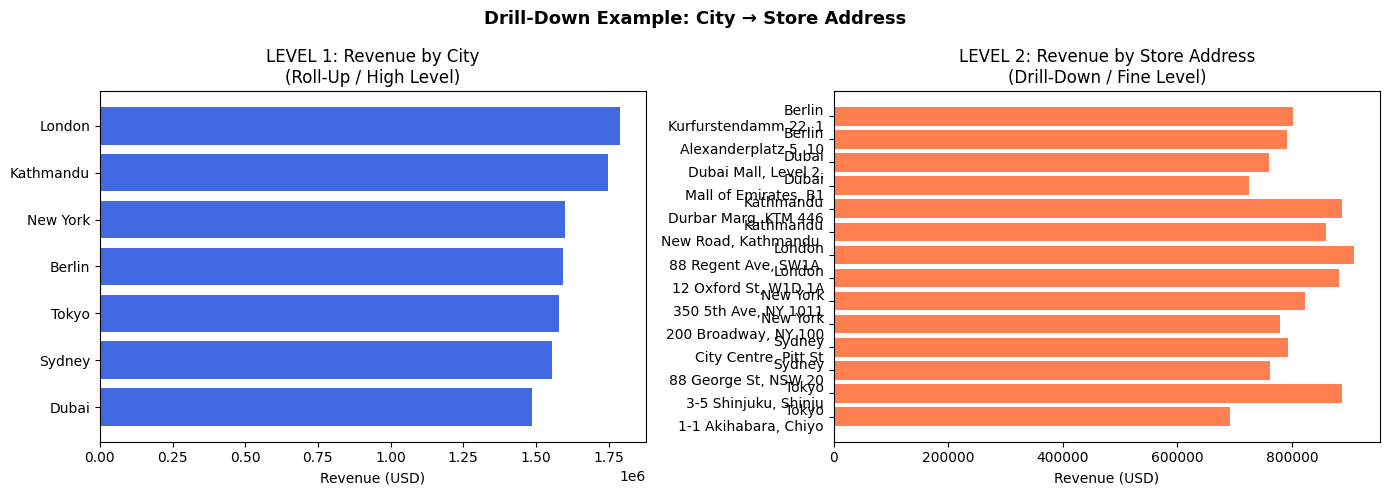

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: City level
axes[0].barh(city_level['CITY'], city_level['CITY_REVENUE'], color='royalblue')
axes[0].set_title("LEVEL 1: Revenue by City\n(Roll-Up / High Level)")
axes[0].set_xlabel("Revenue (USD)")
axes[0].invert_yaxis()

# RIGHT: Store level
store_level['LABEL'] = store_level['CITY'] + '\n' + store_level['STORE_ADDRESS'].str[:20]
axes[1].barh(store_level['LABEL'], store_level['STORE_REVENUE'], color='coral')
axes[1].set_title("LEVEL 2: Revenue by Store Address\n(Drill-Down / Fine Level)")
axes[1].set_xlabel("Revenue (USD)")
axes[1].invert_yaxis()

plt.suptitle("Drill-Down Example: City → Store Address",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 39 – OLAP ROLL-UP: Daily → Monthly → Quarterly → Yearly

In [93]:
print("=" * 55)
print("  ROLL-UP: Daily → Monthly → Quarterly → Yearly")
print("=" * 55)

# DAILY
daily = dw_df.groupby('DATE')['REVENUE'].sum().reset_index()
print(f"\n▶ Daily Level ({len(daily)} rows) — Sample:")
print(daily.head(5).to_string(index=False))

# MONTHLY
monthly = dw_df.groupby(['YEAR','MONTH_NUM','MONTH'])['REVENUE'].sum().reset_index()
monthly = monthly.sort_values(['YEAR','MONTH_NUM'])
print(f"\n▶ Monthly Roll-Up ({len(monthly)} rows) — Sample:")
print(monthly[['YEAR','MONTH','REVENUE']].head(6).to_string(index=False))

# QUARTERLY
quarterly = dw_df.groupby(['YEAR','QUARTER'])['REVENUE'].sum().reset_index()
print(f"\n▶ Quarterly Roll-Up ({len(quarterly)} rows):")
print(quarterly.to_string(index=False))

# YEARLY (Apex)
yearly = dw_df.groupby('YEAR')['REVENUE'].sum().reset_index()
print(f"\n▶ Yearly Roll-Up (Total Apex):")
print(yearly.to_string(index=False))

  ROLL-UP: Daily → Monthly → Quarterly → Yearly

▶ Daily Level (364 rows) — Sample:
      DATE  REVENUE
2024-01-01 24512.08
2024-01-02 42442.47
2024-01-03 59944.11
2024-01-04 24351.57
2024-01-05 31139.60

▶ Monthly Roll-Up (12 rows) — Sample:
 YEAR    MONTH    REVENUE
 2024  January 1058509.80
 2024 February  757264.03
 2024    March  892266.88
 2024    April  914023.09
 2024      May  954615.54
 2024     June  961131.85

▶ Quarterly Roll-Up (4 rows):
 YEAR QUARTER    REVENUE
 2024      Q1 2708040.71
 2024      Q2 2829770.48
 2024      Q3 2959875.41
 2024      Q4 2848183.90

▶ Yearly Roll-Up (Total Apex):
 YEAR    REVENUE
 2024 11345870.5


## Cell 40 – ROLL-UP Visualization: All Time Levels

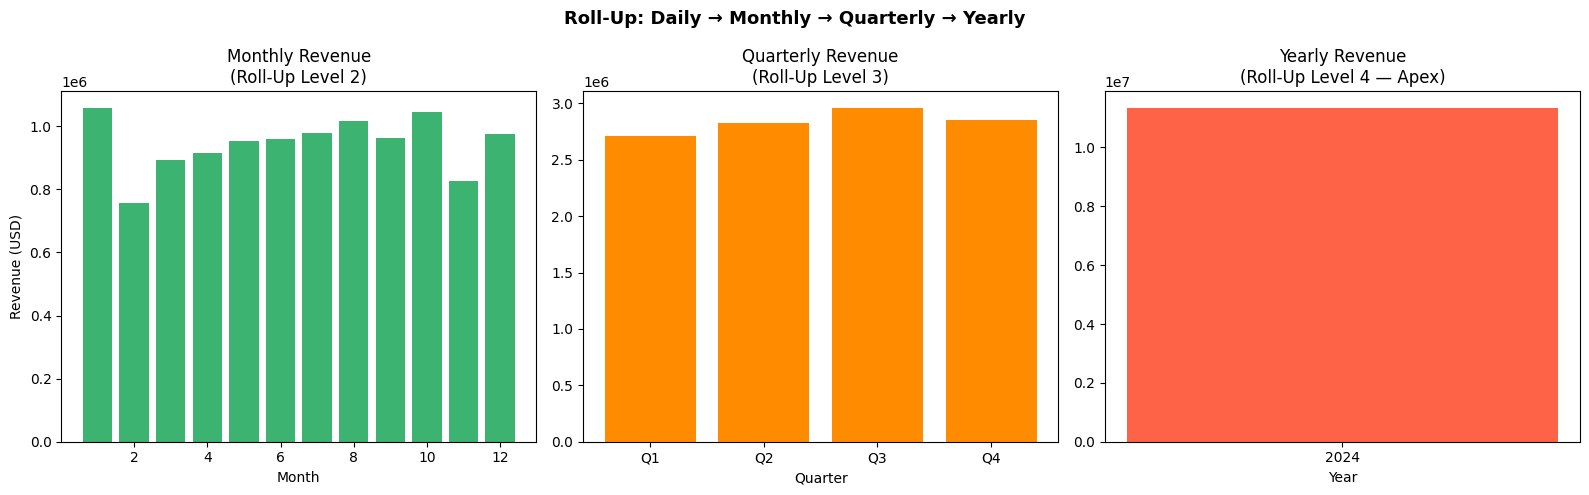

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Monthly
axes[0].bar(monthly['MONTH_NUM'], monthly['REVENUE'], color='mediumseagreen')
axes[0].set_title("Monthly Revenue\n(Roll-Up Level 2)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue (USD)")

# Quarterly
axes[1].bar(quarterly['QUARTER'], quarterly['REVENUE'], color='darkorange')
axes[1].set_title("Quarterly Revenue\n(Roll-Up Level 3)")
axes[1].set_xlabel("Quarter")

# Yearly
axes[2].bar(yearly['YEAR'].astype(str), yearly['REVENUE'], color='tomato')
axes[2].set_title("Yearly Revenue\n(Roll-Up Level 4 — Apex)")
axes[2].set_xlabel("Year")

plt.suptitle("Roll-Up: Daily → Monthly → Quarterly → Yearly",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 41 – OLAP PIVOT TABLE: Product × City Heatmap

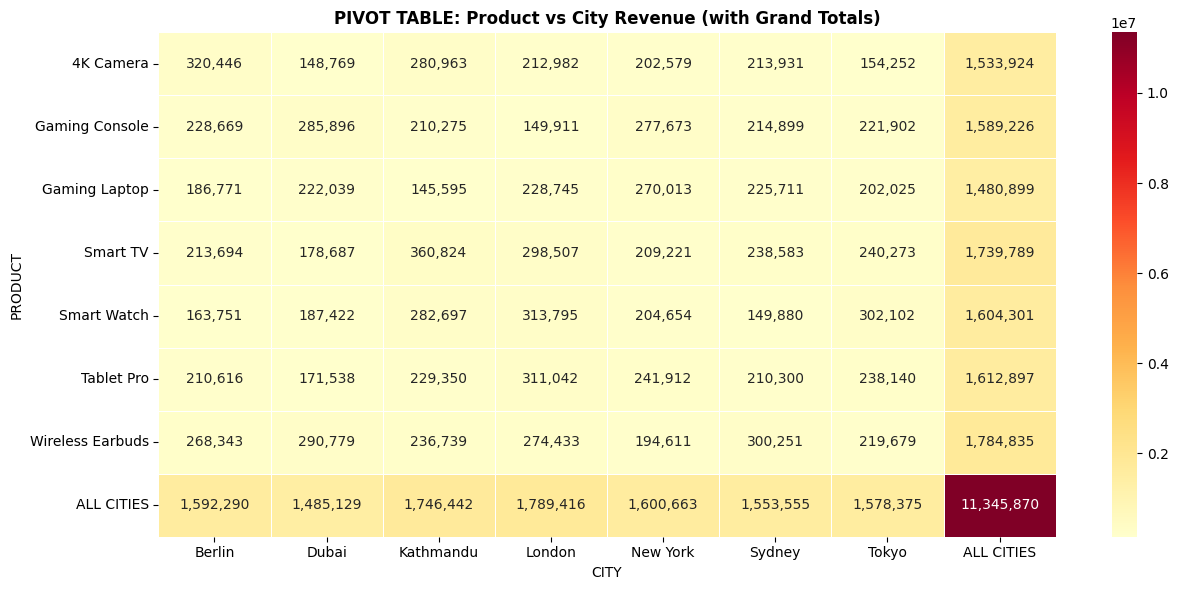

In [95]:
pivot = dw_df.pivot_table(
    values='REVENUE', index='PRODUCT', columns='CITY',
    aggfunc='sum', margins=True, margins_name='ALL CITIES'
)

plt.figure(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white')
plt.title("PIVOT TABLE: Product vs City Revenue (with Grand Totals)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 42 – OLAP TOP-N: Top 3 Cities by Revenue

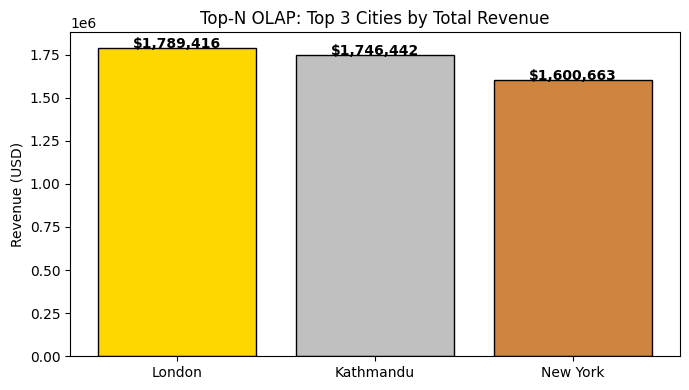

Top 3 Cities:
     CITY    REVENUE
   London 1789415.92
Kathmandu 1746442.06
 New York 1600663.08


In [96]:
top3_cities = dw_df.groupby('CITY')['REVENUE'].sum().nlargest(3).reset_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(top3_cities['CITY'], top3_cities['REVENUE'],
               color=['gold','silver','peru'], edgecolor='black')
for bar, val in zip(bars, top3_cities['REVENUE']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.title("Top-N OLAP: Top 3 Cities by Total Revenue")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

print("Top 3 Cities:")
print(top3_cities.to_string(index=False))

## Cell 43 – Top-N: Top 2 Products by Quantity Sold

Top 2 Products by Units Sold:
         PRODUCT  QUANTITY
Wireless Earbuds    1416.0
        Smart TV    1336.0


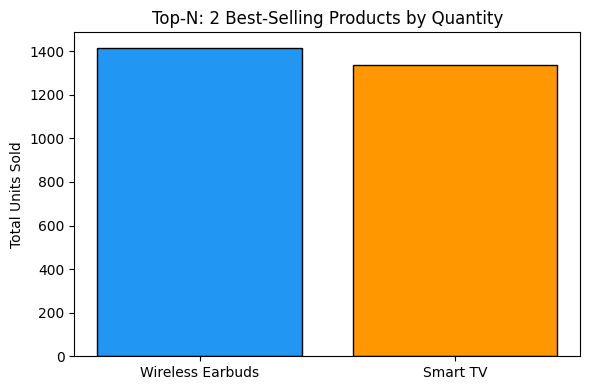

In [97]:
top2_qty = dw_df.groupby('PRODUCT')['QUANTITY'].sum().nlargest(2).reset_index()

print("Top 2 Products by Units Sold:")
print(top2_qty.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(top2_qty['PRODUCT'], top2_qty['QUANTITY'], color=['#2196F3','#FF9800'], edgecolor='black')
plt.title("Top-N: 2 Best-Selling Products by Quantity")
plt.ylabel("Total Units Sold")
plt.tight_layout()
plt.show()

---
## PART 6: DATA CUBE AND CUBOID LATTICE
---

## Cell 44 – Apex Cuboid and Base Cuboid

In [98]:
# Apex Cuboid: Grand total (0-D)
apex = dw_df['REVENUE'].sum()

# Base Cuboid: Most granular level (all dimensions)
base_cuboid = dw_df.groupby(['DATE', 'CITY', 'STORE_ADDRESS', 'PRODUCT', 'CATEGORY'])['REVENUE'].sum()

# Intermediate Cuboids
cuboid_city_product = dw_df.groupby(['CITY','PRODUCT'])['REVENUE'].sum().reset_index()
cuboid_qtr_product  = dw_df.groupby(['QUARTER','PRODUCT'])['REVENUE'].sum().reset_index()

print(f"{'='*50}")
print(f"  DATA CUBE CUBOID HIERARCHY")
print(f"{'='*50}")
print(f"  Apex Cuboid   (Grand Total)  : ${apex:,.2f}")
print(f"  Base Cuboid   (Granular)     : {len(base_cuboid)} unique cells")
print(f"  City×Product Cuboid          : {len(cuboid_city_product)} cells")
print(f"  Quarter×Product Cuboid       : {len(cuboid_qtr_product)} cells")

print("\n--- Base Cuboid Sample (Top 10 rows) ---")
print(base_cuboid.head(10))

  DATA CUBE CUBOID HIERARCHY
  Apex Cuboid   (Grand Total)  : $11,345,870.50
  Base Cuboid   (Granular)     : 2176 unique cells
  City×Product Cuboid          : 49 cells
  Quarter×Product Cuboid       : 28 cells

--- Base Cuboid Sample (Top 10 rows) ---
DATE        CITY      STORE_ADDRESS              PRODUCT           CATEGORY 
2024-01-01  London    12 Oxford St, W1D 1AB      Smart Watch       Wearables     8459.88
                      88 Regent Ave, SW1A 2AA    Gaming Console    Gaming        4176.28
            New York  200 Broadway, NY 10007     Smart TV          Display      11875.92
2024-01-02  London    88 Regent Ave, SW1A 2AA    Gaming Laptop     Computing     6884.95
            New York  200 Broadway, NY 10007     Wireless Earbuds  Audio          798.80
                      350 5th Ave, NY 10118      Gaming Console    Gaming       12756.17
            Tokyo     1-1 Akihabara, Chiyoda     Tablet Pro        Computing    15970.85
                      3-5 Shinjuku, Shinjuku-k

## Cell 45 – Cuboid Lattice Diagram (Text Visual)

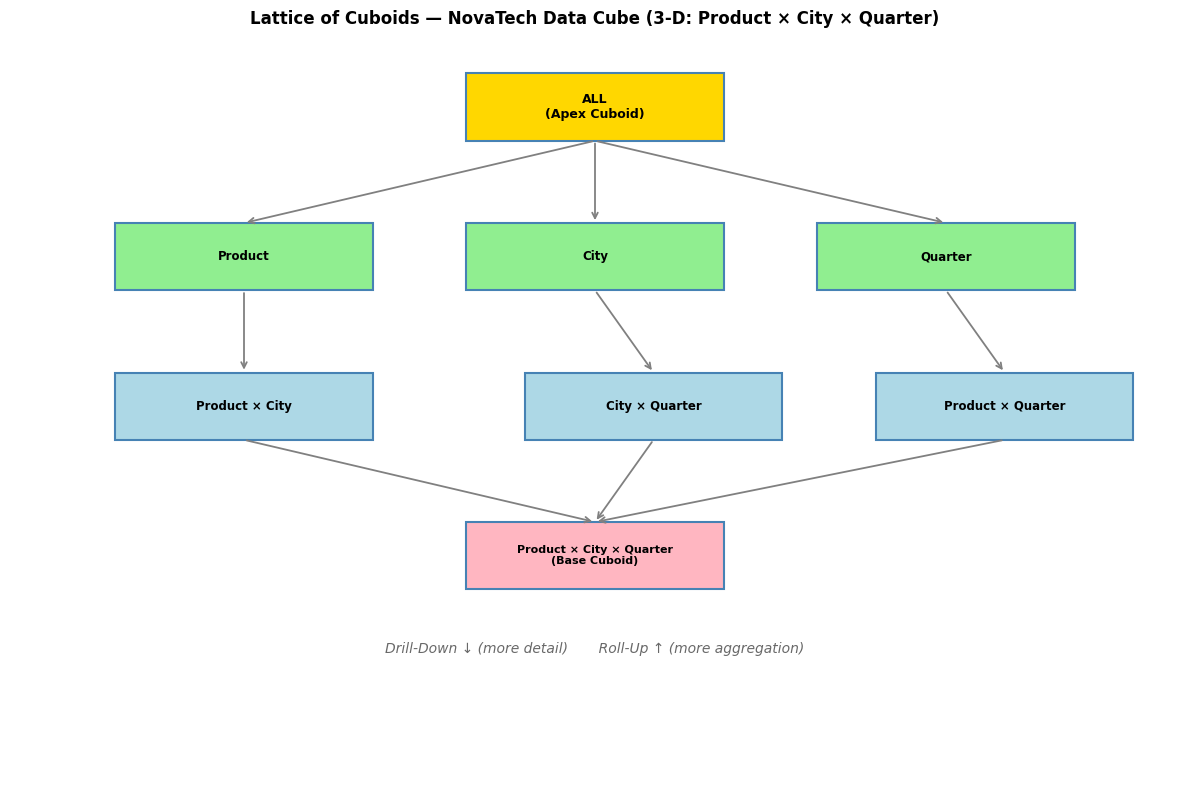

In [99]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.axis('off')

def box(ax, x, y, text, color='#E8F4FD', fs=8.5):
    ax.add_patch(plt.Rectangle((x-1.1, y-0.45), 2.2, 0.9,
                               facecolor=color, edgecolor='steelblue', linewidth=1.5, zorder=2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight='bold', zorder=3)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2+0.45), xytext=(x1, y1-0.45),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.3))

# Level 0 — Apex
box(ax, 5, 9, 'ALL\n(Apex Cuboid)', '#FFD700', fs=9)

# Level 1 — single dimension
box(ax, 2, 7, 'Product', '#90EE90')
box(ax, 5, 7, 'City', '#90EE90')
box(ax, 8, 7, 'Quarter', '#90EE90')

# Level 2 — two dimensions
box(ax, 2, 5, 'Product × City', '#ADD8E6')
box(ax, 5.5, 5, 'City × Quarter', '#ADD8E6')
box(ax, 8.5, 5, 'Product × Quarter', '#ADD8E6')

# Level 3 — three dimensions (Base)
box(ax, 5, 3, 'Product × City × Quarter\n(Base Cuboid)', '#FFB6C1', fs=8)

# Arrows
for xi in [2, 5, 8]: arrow(ax, 5, 9, xi, 7)
arrow(ax, 2, 7, 2, 5); arrow(ax, 5, 7, 5.5, 5); arrow(ax, 8, 7, 8.5, 5)
for xi in [2, 5.5, 8.5]: arrow(ax, xi, 5, 5, 3)

ax.text(5, 1.7, 'Drill-Down ↓ (more detail)       Roll-Up ↑ (more aggregation)',
        ha='center', fontsize=10, style='italic', color='dimgray')

ax.set_title("Lattice of Cuboids — NovaTech Data Cube (3-D: Product × City × Quarter)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 46 – 3D Scatter: Interactive Data Cube View

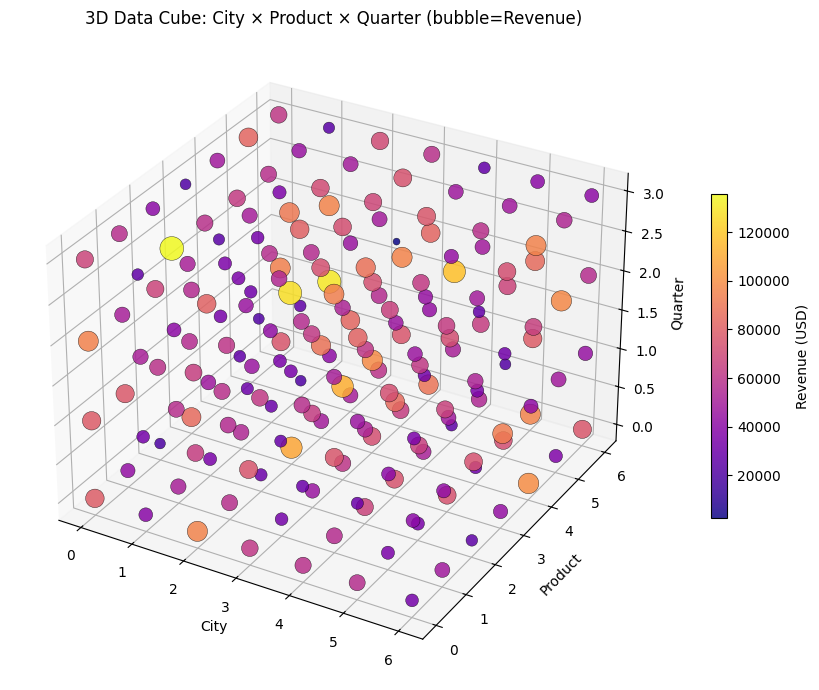

In [100]:
cube_3d = dw_df.groupby(['CITY','PRODUCT','QUARTER'])['REVENUE'].sum().reset_index()

# Encode to numbers for 3D plot
cube_3d['CITY_NUM']    = cube_3d['CITY'].astype('category').cat.codes
cube_3d['PRODUCT_NUM'] = cube_3d['PRODUCT'].astype('category').cat.codes
cube_3d['QUARTER_NUM'] = cube_3d['QUARTER'].astype('category').cat.codes

fig = plt.figure(figsize=(11, 7))
ax3d = fig.add_subplot(111, projection='3d')

sc = ax3d.scatter(
    cube_3d['CITY_NUM'], cube_3d['PRODUCT_NUM'], cube_3d['QUARTER_NUM'],
    c=cube_3d['REVENUE'], cmap='plasma', s=cube_3d['REVENUE']/500 + 20,
    alpha=0.85, edgecolors='k', linewidths=0.3
)

ax3d.set_xlabel('City'); ax3d.set_ylabel('Product'); ax3d.set_zlabel('Quarter')
ax3d.set_title("3D Data Cube: City × Product × Quarter (bubble=Revenue)")

plt.colorbar(sc, ax=ax3d, shrink=0.5, label='Revenue (USD)')
plt.tight_layout()
plt.show()

---
## PART 7: CURSE OF DIMENSIONALITY
---

## Cell 47 – Curse of Dimensionality: Sparsity Calculation

In [101]:
n_products  = dw_df['PRODUCT'].nunique()
n_cities    = dw_df['CITY'].nunique()
n_quarters  = dw_df['QUARTER'].nunique()
n_months    = dw_df['MONTH'].nunique()
n_stores    = dw_df['STORE_ADDRESS'].nunique()

# 3-D cube
total_3d  = n_products * n_cities * n_quarters
actual_3d = dw_df.groupby(['PRODUCT','CITY','QUARTER']).ngroups
sparse_3d = (1 - actual_3d / total_3d) * 100

# 5-D cube (add Month and Store)
total_5d  = n_products * n_cities * n_quarters * n_months * n_stores
actual_5d = dw_df.groupby(['PRODUCT','CITY','QUARTER','MONTH','STORE_ADDRESS']).ngroups
sparse_5d = (1 - actual_5d / total_5d) * 100

print("=" * 55)
print("  CURSE OF DIMENSIONALITY — Sparsity Analysis")
print("=" * 55)
print(f"  Products  : {n_products}  |  Cities : {n_cities}")
print(f"  Quarters  : {n_quarters}  |  Months : {n_months}  |  Stores: {n_stores}")
print()
print(f"  3-D Cube (P×C×Q): {total_3d:,} possible cells | {actual_3d:,} actual | Sparsity: {sparse_3d:.1f}%")
print(f"  5-D Cube (P×C×Q×M×S): {total_5d:,} possible cells | {actual_5d:,} actual | Sparsity: {sparse_5d:.1f}%")
print()
print("⚠️  As dimensions grow, most cube cells become EMPTY (sparse).")
print("   This wastes memory and degrades query performance.")

  CURSE OF DIMENSIONALITY — Sparsity Analysis
  Products  : 7  |  Cities : 7
  Quarters  : 4  |  Months : 12  |  Stores: 14

  3-D Cube (P×C×Q): 196 possible cells | 196 actual | Sparsity: 0.0%
  5-D Cube (P×C×Q×M×S): 32,928 possible cells | 988 actual | Sparsity: 97.0%

⚠️  As dimensions grow, most cube cells become EMPTY (sparse).
   This wastes memory and degrades query performance.


## Cell 48 – Curse of Dimensionality: Exponential Growth Visualization

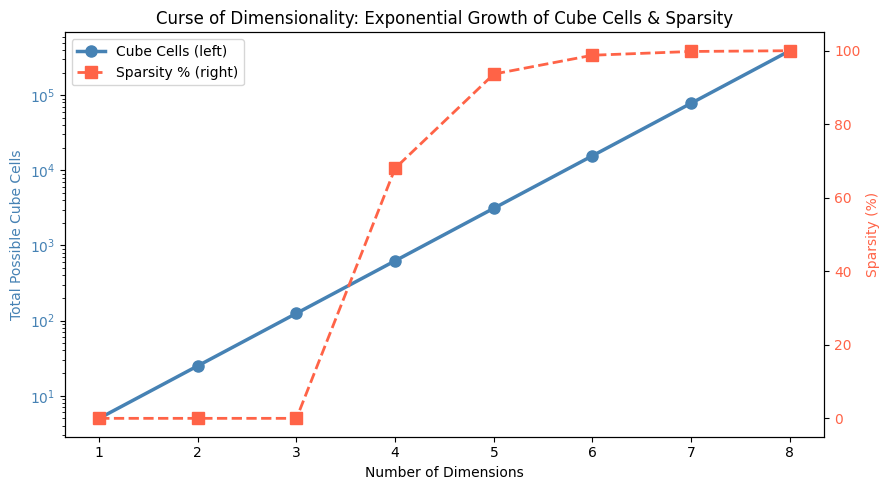

Remedy: Pre-compute only relevant cuboids, use PCA/dimensionality reduction.


In [102]:
dims  = [1, 2, 3, 4, 5, 6, 7, 8]
cells = [5**d for d in dims]       # 5 values per dimension
sparse_pct = [max(0, (1 - 200 / c) * 100) for c in cells]  # Sparsity grows fast

fig, ax1 = plt.subplots(figsize=(9, 5))

color1 = 'steelblue'
ax1.plot(dims, cells, 'o-', color=color1, linewidth=2.5, markersize=8, label='Cube Cells (left)')
ax1.set_xlabel('Number of Dimensions')
ax1.set_ylabel('Total Possible Cube Cells', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_yscale('log')

ax2 = ax1.twinx()
ax2.plot(dims, sparse_pct, 's--', color='tomato', linewidth=2, markersize=8, label='Sparsity % (right)')
ax2.set_ylabel('Sparsity (%)', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title("Curse of Dimensionality: Exponential Growth of Cube Cells & Sparsity")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()
print("Remedy: Pre-compute only relevant cuboids, use PCA/dimensionality reduction.")

---
## PART 8: STANDARDIZATION & PCA (Dimensionality Reduction)
---

## Cell 49 – Encode Categorical Features and Standardize

In [103]:
pca_df = dw_df.copy()
pca_df['PROD_ENC']  = pca_df['PRODUCT'].astype('category').cat.codes
pca_df['CITY_ENC']  = pca_df['CITY'].astype('category').cat.codes
pca_df['QTR_ENC']   = pca_df['QUARTER'].astype('category').cat.codes

features = ['REVENUE', 'QUANTITY', 'UNIT_PRICE', 'PROD_ENC', 'CITY_ENC', 'QTR_ENC']
X = pca_df[features]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Features standardized (mean=0, std=1).")
print(f"   Feature matrix shape: {X_scaled.shape}")
print("\nStandardized feature stats:")
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))

✅ Features standardized (mean=0, std=1).
   Feature matrix shape: (2242, 6)

Standardized feature stats:
        REVENUE  QUANTITY  UNIT_PRICE  PROD_ENC  CITY_ENC   QTR_ENC
count  2242.000  2242.000    2242.000  2242.000  2242.000  2242.000
mean      0.000     0.000      -0.000     0.000     0.000     0.000
std       1.000     1.000       1.000     1.000     1.000     1.000
min      -1.244    -1.507      -1.705    -1.542    -1.521    -1.369
25%      -0.806    -1.004      -0.874    -1.042    -1.018    -0.465
50%      -0.260     0.002      -0.027    -0.041    -0.012     0.439
75%       0.603     1.008       0.883     0.960     0.995     0.439
max       3.060     1.511       1.743     1.460     1.498     1.343


## Cell 50 – Before PCA: High-Dimensional Scatter (3D View)

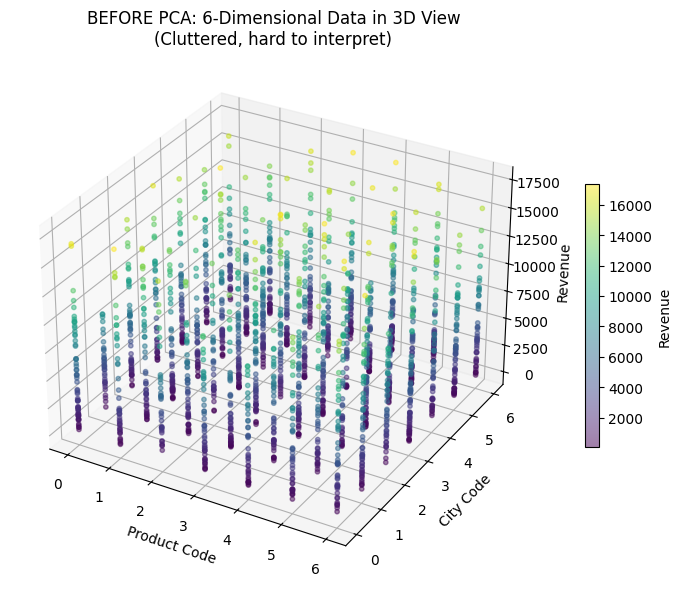

In [104]:
fig = plt.figure(figsize=(10, 6))
ax  = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pca_df['PROD_ENC'], pca_df['CITY_ENC'], pca_df['REVENUE'],
    c=pca_df['REVENUE'], cmap='viridis', alpha=0.5, s=10
)
ax.set_xlabel('Product Code'); ax.set_ylabel('City Code'); ax.set_zlabel('Revenue')
ax.set_title("BEFORE PCA: 6-Dimensional Data in 3D View\n(Cluttered, hard to interpret)")
plt.colorbar(sc, ax=ax, shrink=0.5, label='Revenue')
plt.tight_layout()
plt.show()

## Cell 51 – After PCA: Compress to 2 Principal Components

PC1 explains : 32.52% of variance
PC2 explains : 17.86% of variance
Total        : 50.38%


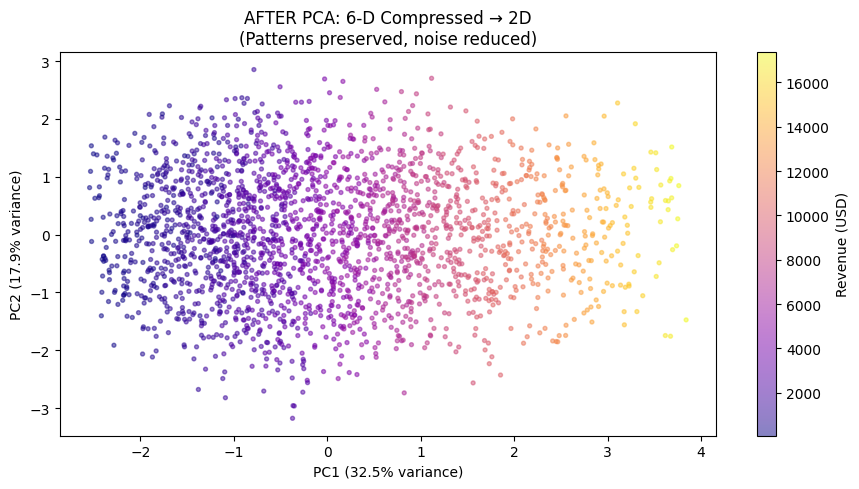

In [105]:
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance_explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains : {variance_explained[0]:.2f}% of variance")
print(f"PC2 explains : {variance_explained[1]:.2f}% of variance")
print(f"Total        : {sum(variance_explained):.2f}%")

plt.figure(figsize=(9, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=pca_df['REVENUE'], cmap='plasma', alpha=0.5, s=8)
plt.colorbar(scatter, label='Revenue (USD)')
plt.xlabel(f"PC1 ({variance_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({variance_explained[1]:.1f}% variance)")
plt.title("AFTER PCA: 6-D Compressed → 2D\n(Patterns preserved, noise reduced)")
plt.tight_layout()
plt.show()

## Cell 52 – PCA Variance Explained Bar Chart

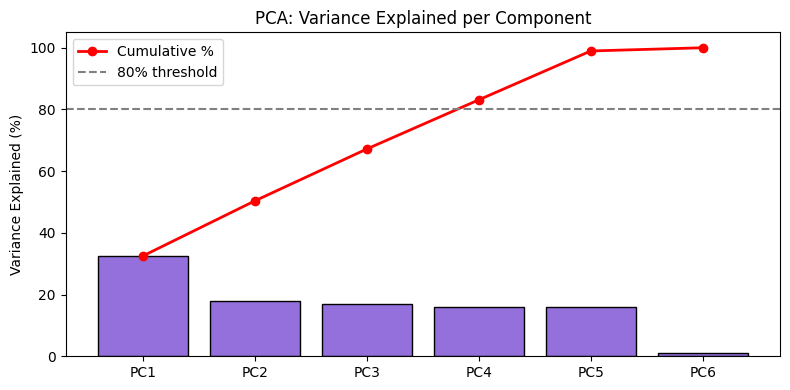


2 components retain 50.4% of total information.


In [106]:
pca_full   = PCA(n_components=6)
pca_full.fit(X_scaled)
var_all    = pca_full.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 4))
plt.bar([f'PC{i+1}' for i in range(6)], var_all, color='mediumpurple', edgecolor='black')
plt.plot([f'PC{i+1}' for i in range(6)], np.cumsum(var_all),
         'ro-', linewidth=2, label='Cumulative %')
plt.axhline(y=80, color='gray', linestyle='--', label='80% threshold')
plt.title("PCA: Variance Explained per Component")
plt.ylabel("Variance Explained (%)")
plt.legend()
plt.tight_layout()
plt.show()
print(f"\n2 components retain {sum(var_all[:2]):.1f}% of total information.")

---
## PART 9: GIT VERSION CONTROL
---

---
## PART 10: FINAL SUMMARY AND WRITTEN ANSWERS
---

## Cell 53 – Why Data Cube is Better Than Flat Excel Spreadsheet

In [109]:
comparison = pd.DataFrame({
    'Capability': [
        'Multi-dimensional analysis',
        'Slice / Dice / Roll-Up / Drill-Down',
        'Handles millions of rows',
        'Pre-aggregated cuboids (fast)',
        'Hierarchical time analysis',
        'PCA / ML integration',
        'Schema enforcement'
    ],
    'Data Cube (OLAP)': ['✅','✅','✅','✅','✅','✅','✅'],
    'Flat Excel Sheet': ['❌','❌ (manual pivot only)','❌ (crashes)','❌','❌','❌','❌']
})

print(comparison.to_string(index=False))

                         Capability Data Cube (OLAP)      Flat Excel Sheet
         Multi-dimensional analysis                ✅                     ❌
Slice / Dice / Roll-Up / Drill-Down                ✅ ❌ (manual pivot only)
           Handles millions of rows                ✅           ❌ (crashes)
      Pre-aggregated cuboids (fast)                ✅                     ❌
         Hierarchical time analysis                ✅                     ❌
               PCA / ML integration                ✅                     ❌
                 Schema enforcement                ✅                     ❌


## Cell 54 – Complete Assignment Summary

In [110]:
print("="*60)
print("  LESSON 2 ASSIGNMENT — COMPLETION SUMMARY")
print("="*60)
checklist = [
    ("✅", "Dataset generation (NumPy, JSON + CSV with noise)"),
    ("✅", "head(10) shown for both sources"),
    ("✅", ".columns and .dtypes inspected"),
    ("✅", "Dimensions and Measures identified"),
    ("✅", "EDA: shape, size, info, describe, nulls, outliers, ranges"),
    ("✅", "EDA: boxplot and histogram visualizations"),
    ("✅", "Mean and Max of REVENUE computed"),
    ("✅", "Cleaning: coercion, imputation, drop, filter"),
    ("✅", "Feature engineering: REVENUE, QUARTER, YEAR, MONTH, WEEK"),
    ("✅", "Store address assigned for Drill-Down"),
    ("✅", "Star Schema built and visualized"),
    ("✅", "Snowflake Schema built and visualized"),
    ("✅", "Fact Constellation Schema built and visualized"),
    ("✅", "SLICE: Q1 sales filtered and visualized"),
    ("✅", "DICE: Smart TV × London × Q1 filtered and visualized"),
    ("✅", "DRILL-DOWN: City → Store Address"),
    ("✅", "ROLL-UP: Daily → Monthly → Quarterly → Yearly"),
    ("✅", "PIVOT: Product × City heatmap"),
    ("✅", "TOP-N: Top 3 Cities, Top 2 Products"),
    ("✅", "Apex Cuboid and Base Cuboid computed"),
    ("✅", "Lattice of Cuboids diagram"),
    ("✅", "3D Data Cube scatter plot"),
    ("✅", "Curse of Dimensionality: sparsity & exponential growth"),
    ("✅", "PCA: standardization, before/after, variance chart"),
    ("✅", "Data saved to CSV and JSON"),
    ("✅", "Git version control commands provided"),
    ("✅", "Data Cube vs Flat Excel comparison table"),
]
for icon, item in checklist:
    print(f"  {icon}  {item}")

print("\n" + "="*60)
print(f"  Total Clean Records Used  : {len(dw_df):,}")
print(f"  Total Revenue (Dataset)   : ${dw_df['REVENUE'].sum():,.2f}")
print(f"  Products                  : {dw_df['PRODUCT'].nunique()}")
print(f"  Cities                    : {dw_df['CITY'].nunique()}")
print("="*60)

  LESSON 2 ASSIGNMENT — COMPLETION SUMMARY
  ✅  Dataset generation (NumPy, JSON + CSV with noise)
  ✅  head(10) shown for both sources
  ✅  .columns and .dtypes inspected
  ✅  Dimensions and Measures identified
  ✅  EDA: shape, size, info, describe, nulls, outliers, ranges
  ✅  EDA: boxplot and histogram visualizations
  ✅  Mean and Max of REVENUE computed
  ✅  Cleaning: coercion, imputation, drop, filter
  ✅  Feature engineering: REVENUE, QUARTER, YEAR, MONTH, WEEK
  ✅  Store address assigned for Drill-Down
  ✅  Star Schema built and visualized
  ✅  Snowflake Schema built and visualized
  ✅  Fact Constellation Schema built and visualized
  ✅  SLICE: Q1 sales filtered and visualized
  ✅  DICE: Smart TV × London × Q1 filtered and visualized
  ✅  DRILL-DOWN: City → Store Address
  ✅  ROLL-UP: Daily → Monthly → Quarterly → Yearly
  ✅  PIVOT: Product × City heatmap
  ✅  TOP-N: Top 3 Cities, Top 2 Products
  ✅  Apex Cuboid and Base Cuboid computed
  ✅  Lattice of Cuboids diagram
  ✅  3D Dat